**Introduction:** Medical insurance claim prediction is an important application of data analysis and machine learning in the healthcare and insurance industries. By analyzing personal and demographic factors such as age, gender, BMI, number of dependents, smoking habits, and region, it is possible to estimate an individual’s medical insurance charges. Accurate prediction of insurance claim amounts can help insurance companies assess risk, set fair premiums, and improve financial planning. It can also help individuals better understand the factors that influence healthcare costs. In this project, the Medical Cost Personal Dataset is used to build a predictive model that estimates medical insurance claim amounts based on personal data.

**Problem Statement:** The objective of this project is to develop a machine learning model that predicts medical insurance claim amounts using personal and demographic information from the Medical Cost Personal Dataset. The challenge is to identify the relationship between features such as age, BMI, smoking status, number of children, sex, and region, and use these variables to accurately estimate insurance charges. This problem is treated as a regression task, where the goal is to minimize prediction error and generate reliable claim amount estimates.

In [ ]:
#Import the pandas library
#Pandas is used for data handling and analysis

import pandas as pd

#Upload dataset file from your computer

from google.colab import files
uploaded = files.upload()

#Load the uploaded CSV dataset

df = pd.read_csv('insurance.csv')

#Display first 5 rows of dataset
#Helps verify data loaded correctly

print("First 5 Rows of Dataset:")
print(df.head())

Saving insurance.csv to insurance.csv
First 5 Rows of Dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


**Data understanding and description:** The Medical Cost Personal Dataset contains personal and demographic information of individuals, which is used to predict medical insurance claim amounts. Each record in the dataset represents one individual and includes several independent variables (features) along with one dependent variable (target). Understanding the dataset is an important first step before performing preprocessing, exploratory data analysis, and model building.

The dataset includes the following features:

**Age:** Represents the age of the insured individual. Age may influence medical expenses, as healthcare costs often increase with age.

**Sex:** Indicates the gender of the individual (male or female). This categorical feature may have an impact on insurance charges.

**BMI (Body Mass Index):** Measures body fat based on height and weight. Higher BMI values may be associated with increased health risks and medical costs.

**Children:** Represents the number of dependents covered under the insurance plan. This may affect insurance expenses.

**Smoker:** Indicates whether the individual is a smoker or non-smoker. Smoking status is a significant factor that can strongly influence medical claim amounts.

**Region:** Specifies the residential area of the individual (such as southeast, southwest, northeast, northwest). This categorical feature may capture regional differences in healthcare costs.

**Charges:** Represents the medical insurance claim amount or insurance charges billed to the individual. This is the target variable the model aims to predict.

This dataset contains both numerical features (age, BMI, children) and categorical features (sex, smoker, region), making it suitable for applying preprocessing techniques such as encoding before model training. Since the target variable, charges, is continuous, this problem is treated as a regression task where the goal is to estimate insurance claim amounts as accurately as possible.

In [ ]:
#Check dataset shape
#Shows number of rows and columns

print("\nDataset Shape:")
print(df.shape)

#Display column names
#Helps understand available features

print("\nColumn Names:")
print(df.columns)

#Basic dataset information
#Shows data types and missing values

print("\nDataset Information:")
print(df.info())


Dataset Shape:
(1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


**Dataset Cleaning and Preparation:** It is an essential step before building a machine learning model, as it ensures the data is accurate, consistent, and suitable for analysis. In this project, the Medical Cost Personal Dataset was prepared by checking for missing values, duplicate records, incorrect data types, and potential inconsistencies in the data. Missing values, if present, were handled appropriately to avoid errors during model training, while duplicate entries were identified and removed to maintain data quality.

The dataset contains both numerical and categorical features, so preprocessing was required before applying machine learning algorithms. Categorical variables such as sex, smoker, and region were encoded into numerical form using suitable encoding techniques, since machine learning models cannot directly process text-based categories. In addition, feature scaling or normalization may be applied when required by certain algorithms to ensure numerical variables are on a comparable scale.

During preparation, irrelevant or unnecessary features were reviewed, and the target variable (charges) was separated from the input features. The cleaned dataset was then structured for exploratory data analysis and model training. These steps help improve model performance, reduce errors, and ensure reliable prediction of insurance claim amounts.

In [ ]:
#Check for missing values
#Count missing values in each column

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

#Check for duplicate records
#Count duplicate rows

duplicates = df.duplicated().sum()
print("\nNumber of Duplicate Records:", duplicates)

#Remove duplicates if any exist

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)


Missing Values in Each Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of Duplicate Records: 1
Dataset Shape After Removing Duplicates:
(1337, 7)


**Exploratory Data Analysis (EDA):**  It helps us understand patterns and relationships between variables before building a machine learning model. In the Medical Cost Personal Dataset, key factors such as age, BMI, and smoking status are expected to have a strong influence on insurance charges.

**Age vs Charges:** Older individuals generally tend to have higher medical expenses because health risks increase with age. Through visualization, we can observe whether insurance charges increase as age increases, which helps confirm a positive relationship between age and cost.

**BMI vs Charges:** BMI (Body Mass Index) indicates whether a person is underweight, normal, overweight, or obese. Higher BMI values are often associated with health complications, which may lead to higher insurance charges. Plotting BMI against charges helps us identify whether medical costs rise with increasing BMI.

**Smoking Status vs Charges:** Smoking is one of the most influential factors in insurance pricing. Smokers are generally at higher risk of serious health conditions, which leads to significantly higher insurance charges compared to non-smokers. Visualizing this relationship helps clearly show the difference in cost distribution between smokers and non-smokers.

These visualizations help us understand feature importance and guide further preprocessing and model selection decisions.

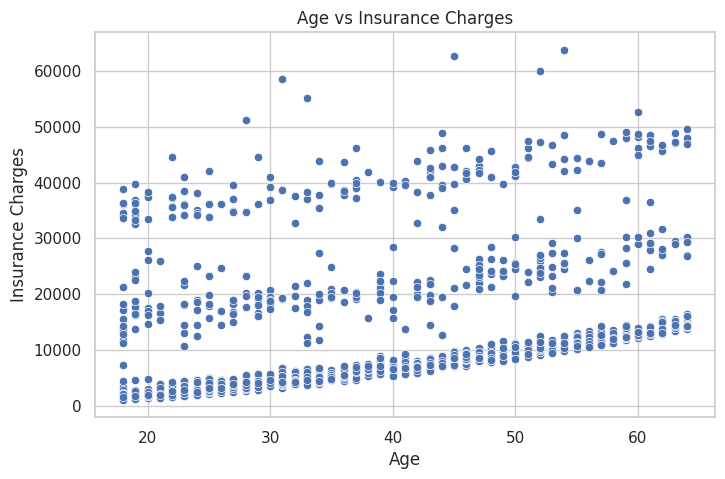

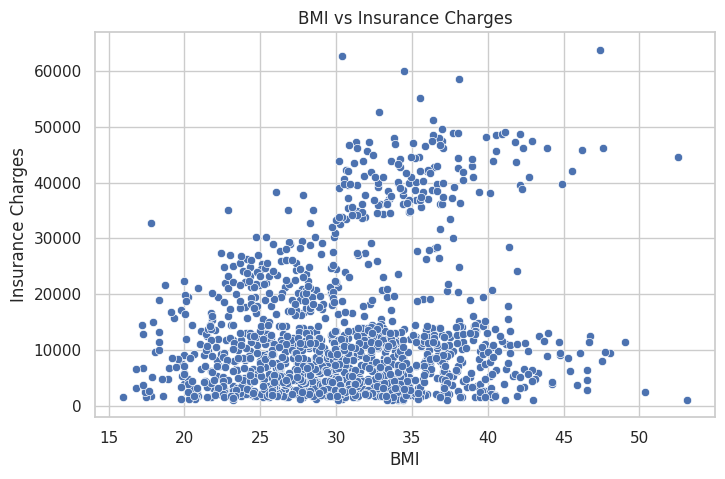

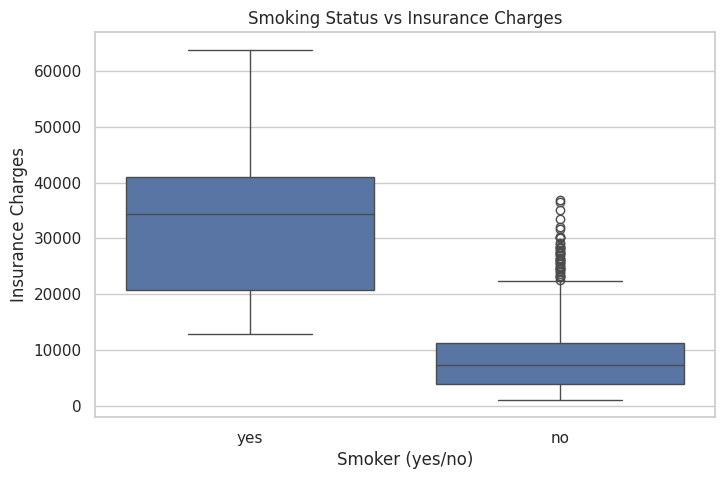

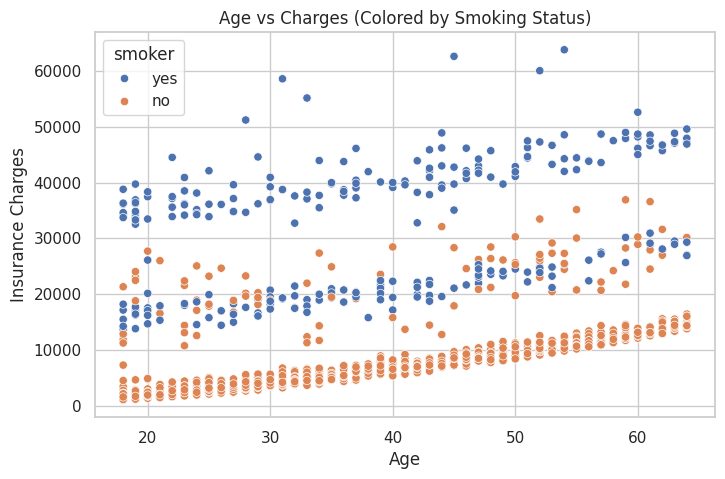

In [ ]:
#EXPLORATORY DATA ANALYSIS (EDA)
#Impact of Age, BMI, and Smoking on Insurance Charges

#Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset

df = pd.read_csv('insurance.csv')

#Set style for better visuals

sns.set(style="whitegrid")

#1. Age vs Insurance Charges

plt.figure(figsize=(8,5))

#Scatter plot to show relationship between age and charges

sns.scatterplot(data=df, x='age', y='charges')

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

#2. BMI vs Insurance Charges

plt.figure(figsize=(8,5))

#Scatter plot to show relationship between BMI and charges

sns.scatterplot(data=df, x='bmi', y='charges')

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

#3. Smoking Status vs Insurance Charges

plt.figure(figsize=(8,5))

#Boxplot to compare smokers vs non-smokers

sns.boxplot(data=df, x='smoker', y='charges')

plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoker (yes/no)")
plt.ylabel("Insurance Charges")
plt.show()

#4. Combined View: Color by Smoking Status
#(Age vs Charges with smoker highlight)

plt.figure(figsize=(8,5))

#Scatter plot with smoking status as hue

sns.scatterplot(data=df, x='age', y='charges', hue='smoker')

plt.title("Age vs Charges (Colored by Smoking Status)")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

Insurance charges generally increase with **age**, showing a positive trend. **Higher BMI** values tend to be associated with higher medical costs. **Smokers** have significantly higher insurance charges compared to non-smokers, making smoking the most influential feature.

These findings confirm that lifestyle and health-related factors strongly affect medical insurance costs and are crucial for prediction modeling.

**Model Training and Testing**: After completing data cleaning and exploratory data analysis, the next step is model training and testing. In this phase, the prepared dataset is divided into training and testing sets. The training data is used to teach the machine learning model the relationship between input features such as age, BMI, smoking status, and insurance charges, while the testing data is used to evaluate how well the model performs on unseen data.

Since predicting insurance claim amounts is a regression problem, suitable regression algorithms such as **Linear Regression** can be used to train the model. During training, the model learns patterns in the data and builds a relationship between independent variables and the target variable (charges).

Model testing is important because it shows how well the model generalizes to new data rather than just memorizing the training data. A well-performing model should produce accurate predictions with minimal error, making it reliable for estimating medical insurance claim amounts.

In [ ]:
#Train a Linear Regression Model to Predict Insurance Charges

#Import required libraries

import pandas as pd

#Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

#Import Linear Regression model

from sklearn.linear_model import LinearRegression

#1. Load Dataset

df = pd.read_csv('insurance.csv')

#2. Convert Categorical Variables into Numerical Form
#Using One-Hot Encoding

df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

#3. Define Features (X) and Target Variable (y)

#Input variables (independent features)

X = df.drop('charges', axis=1)

# Output variable (target)

y = df['charges']

#4. Split Data into Training and Testing Sets

#80% training data
#20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#5. Create Linear Regression Model

model = LinearRegression()

#6. Train (Fit) the Model

#Model learns relationship between features and charges

model.fit(X_train, y_train)

#Confirmation message

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Model Performance Evaluation (MAE and RMSE):** After training the Linear Regression model, the next step is to evaluate how accurately it predicts insurance charges. Model performance evaluation helps measure the difference between actual claim amounts and the values predicted by the model. In this project, Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are used as evaluation metrics.

**Mean Absolute Error (MAE):** MAE measures the average absolute difference between actual and predicted values. It tells us, on average, how much the model’s predictions deviate from the true insurance charges. Lower MAE values indicate better model accuracy.

**Root Mean Squared Error (RMSE):** RMSE measures the square root of the average squared differences between actual and predicted values. It gives greater weight to larger errors, making it useful for identifying models with significant prediction mistakes. Lower RMSE values indicate better model performance.

These metrics help assess how well the regression model generalizes to unseen data and whether it is reliable for predicting medical insurance claim amounts.

In [6]:
#Evaluate Linear Regression Model Performance
#Using MAE and RMSE

#Import required libraries

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

#1. Make Predictions on Test Data
#Use trained model to predict insurance charges

y_pred = model.predict(X_test)

#2. Calculate Mean Absolute Error (MAE)
#Measures average prediction error

mae = mean_absolute_error(y_test, y_pred)

#3. Calculate Root Mean Squared Error (RMSE)
#Measures prediction error with extra penalty for large errors

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#4. Display Evaluation Results

print("Model Performance Results")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Model Performance Results
Mean Absolute Error (MAE): 4181.19447375365
Root Mean Squared Error (RMSE): 5796.284659276273


The **Linear Regression Model** produced a **Mean Absolute Error** of **4181.19** and a **Root Mean Squared Error** of **5796.28**, indicating that predicted insurance charges deviate from actual charges by approximately 4181 on average. The higher RMSE suggests the presence of some larger prediction errors, showing moderate model performance with room for improvement.

**Conclusion:** This project developed a Linear Regression model to predict medical insurance claim amounts using personal factors such as age, BMI, smoking status, number of children, sex, and region. Through exploratory data analysis, key patterns were identified, showing that age, BMI, and especially smoking status have a significant impact on insurance charges. Data cleaning and preprocessing ensured the dataset was suitable for modeling, while the regression model was trained to estimate claim amounts based on these factors.

The model showed reasonable predictive performance, and evaluation metrics provided insight into prediction accuracy and error. Overall, the project demonstrates how machine learning can be used to estimate medical insurance costs and highlights the importance of demographic and lifestyle factors in influencing claim amounts. These findings can support better risk assessment and decision-making in the insurance domain.